### *Load The Dataset for Sentimental analysis on X*

In [2]:
import pandas as pd

df = pd.read_csv("X data.csv")

print(df.head())
print(df.columns)

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0
Index(['clean_text', 'category'], dtype='object')


### *Data Preprocesing*

In [3]:
import re

def clean_text(clean_text):
    text = str(clean_text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    return clean_text

df['clean_text'] = df['clean_text'].apply(clean_text)

### *Perform Sentiment Analysis*

In [4]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.2 MB/s eta 0:00:00


In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))  # ensure it's a string
    if scores['compound'] > 0.05:
        return 'Positive'
    elif scores['compound'] < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply to the text column
df['sentiment'] = df['clean_text'].apply(get_sentiment)

### *Statistical Analysis*

In [6]:
print(df['sentiment'].value_counts())

sentiment
Positive    76486
Negative    50773
Neutral     35721
Name: count, dtype: int64


In [7]:
sentiment_percent = (
    df['sentiment'].value_counts(normalize=True) * 100
)

print(sentiment_percent)

sentiment
Positive    46.929685
Negative    31.152902
Neutral     21.917413
Name: proportion, dtype: float64


### *Visualization*

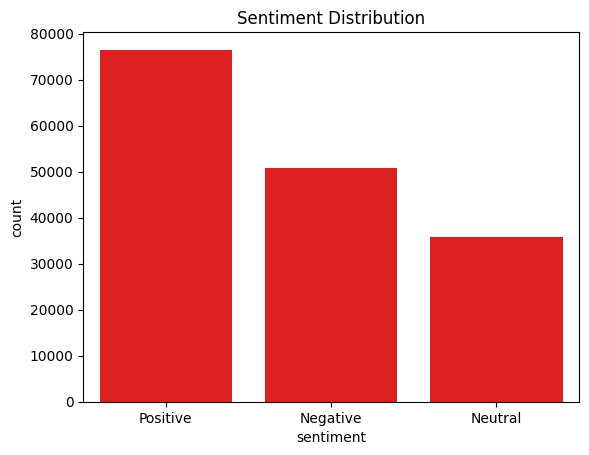

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='sentiment',color="Red")
plt.title('Sentiment Distribution')
plt.show()

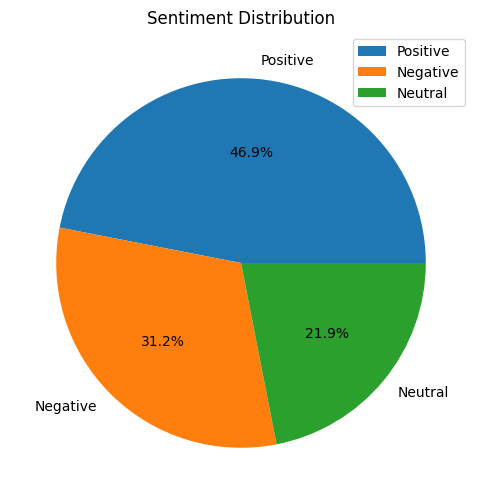

In [9]:
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.ylabel("")
plt.title("Sentiment Distribution")
plt.legend()
plt.grid()
plt.show()

### *WordClouds*

In [10]:
pip install WordCloud

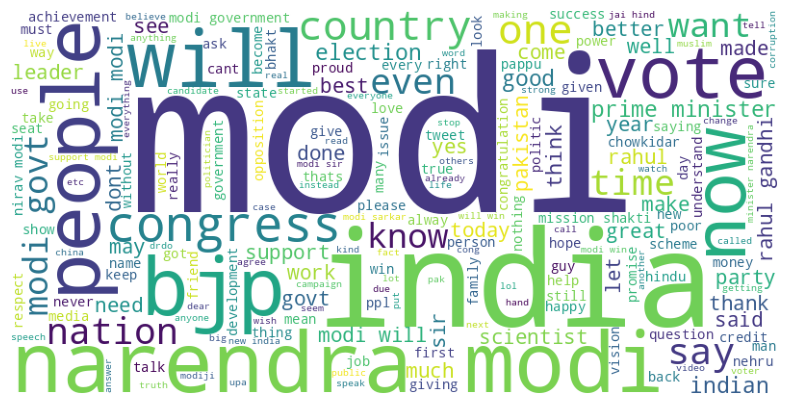

In [11]:
from wordcloud import WordCloud

positive_text = " ".join(
    df[df['sentiment']=="Positive"]['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

### *Time-Series Sentiment Analysis*

In [12]:
from collections import Counter

# Ensure all values are strings
all_words = " ".join(df['clean_text'].astype(str)).split()

word_counts = Counter(all_words)
print(word_counts.most_common(10))  # top 10 words


[('modi', 152373), ('the', 104397), ('and', 67340), ('for', 52414), ('you', 38713), ('not', 29317), ('will', 28910), ('this', 28562), ('india', 28295), ('are', 27994)]


### *Streamlit Application*

In [13]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 39.0 MB/s eta 0:00:00


In [ ]:
%%writefile test_app.py
import streamlit as st
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load the data
df = pd.read_csv("X data.csv")

# Data Preprocessing
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    return text

df['clean_text'] = df['clean_text'].apply(clean_text)

# Perform Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    if scores['compound'] > 0.05:
        return 'Positive'
    elif scores['compound'] < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['clean_text'].apply(get_sentiment)

st.title('Sentiment Analysis Dashboard')
st.write('This is a simple Streamlit app to display sentiment analysis results.')

# Sidebar for filtering
st.sidebar.header("Filter Options")
all_categories = df['category'].unique().tolist()
selected_categories = st.sidebar.multiselect(
    "Select Category",
    all_categories,
    default=all_categories # Select all by default
)

# Filter the DataFrame based on selected categories
if selected_categories:
    filtered_df = df[df['category'].isin(selected_categories)]
else:
    filtered_df = df.copy() # If no categories are selected, show all data

# Display the sentiment distribution from the filtered DataFrame
st.subheader('Sentiment Distribution')
sentiment_counts = filtered_df['sentiment'].value_counts()

# Use matplotlib and st.pyplot to display the bar chart
fig_bar, ax_bar = plt.subplots(figsize=(8, 6))
sentiment_counts.plot(kind='bar', ax=ax_bar, color=['skyblue', 'lightcoral', 'lightgreen'])
ax_bar.set_title('Sentiment Distribution')
ax_bar.set_xlabel('Sentiment')
ax_bar.set_ylabel('Count')
ax_bar.tick_params(axis='x', rotation=45)
st.pyplot(fig_bar)
plt.close(fig_bar) # Close the figure to free up memory

st.subheader('Sentiment Percentage')
sentiment_percent = (filtered_df['sentiment'].value_counts(normalize=True) * 100).round(2)

# Use matplotlib and st.pyplot to display the sentiment percentage table
fig_table, ax_table = plt.subplots(figsize=(6, 2))
ax_table.axis('off') # Hide axes
ax_table.axis('tight') # Adjust layout
table_data = sentiment_percent.reset_index()
table_data.columns = ['Sentiment', 'Percentage']
table = ax_table.table(cellText=table_data.values, colLabels=table_data.columns, loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
st.pyplot(fig_table)
plt.close(fig_table) # Close the figure to free up memory

st.subheader('Word Cloud for Positive Sentiments')

positive_text = " ".join(filtered_df[filtered_df['sentiment']=="Positive"]['clean_text'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

fig_wordcloud, ax_wordcloud = plt.subplots(figsize=(10,5))
ax_wordcloud.imshow(wordcloud, interpolation='bilinear')
ax_wordcloud.axis('off')
st.pyplot(fig_wordcloud)
plt.close(fig_wordcloud)

In [15]:
!streamlit run test_app.py &>/dev/null&

In [16]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 7s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [ ]:
!lt --port 8501

your url is: https://large-sloths-thank.loca.lt
